In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

**Import Libraries**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import os
from PIL import Image

sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(8,5)

**Load Dataset**

In [3]:
metadata = pd.read_csv("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


**Basic Dataset Information**

In [4]:
metadata.shape

(10015, 7)

In [5]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


**Check Missing Values**

In [6]:
metadata.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

*Example visualization:*

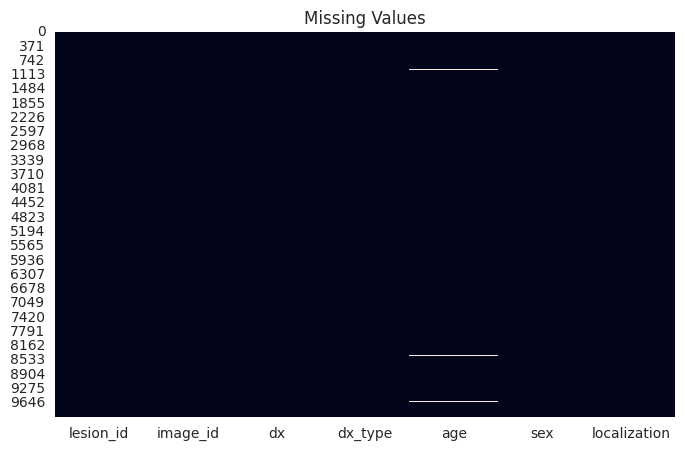

In [7]:
sns.heatmap(metadata.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()

**Statistical Summary**

In [8]:
metadata.describe(include='all')

,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0032258,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


**Duplicated Records**

In [9]:
metadata.duplicated().sum()

np.int64(0)

**Class Distribution**

In [10]:
metadata['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

*Visualization:*

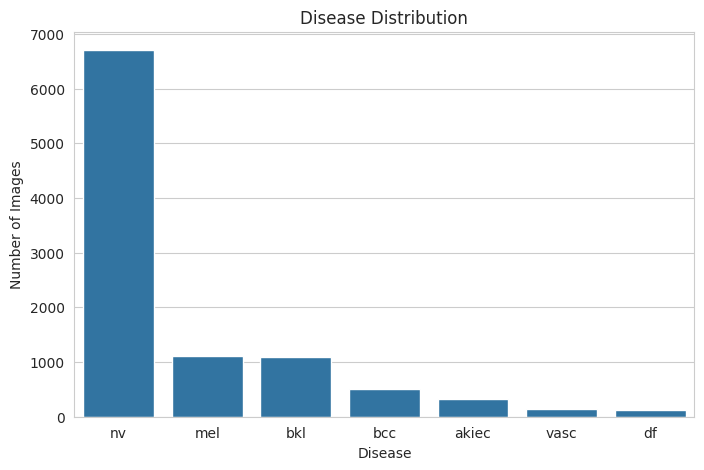

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=metadata,
              x='dx',
              order=metadata['dx'].value_counts().index)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.show()

**Gender Distribution**

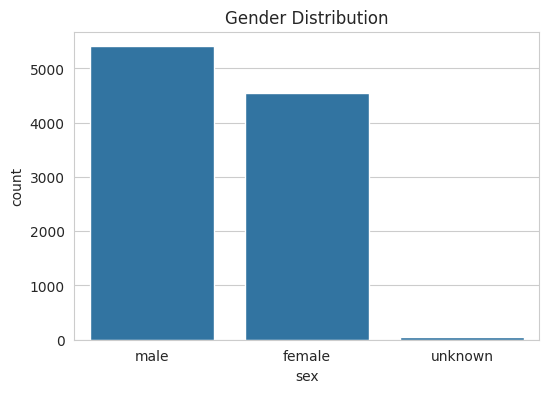

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=metadata,x='sex')

plt.title("Gender Distribution")
plt.show()

**Age Distribution**

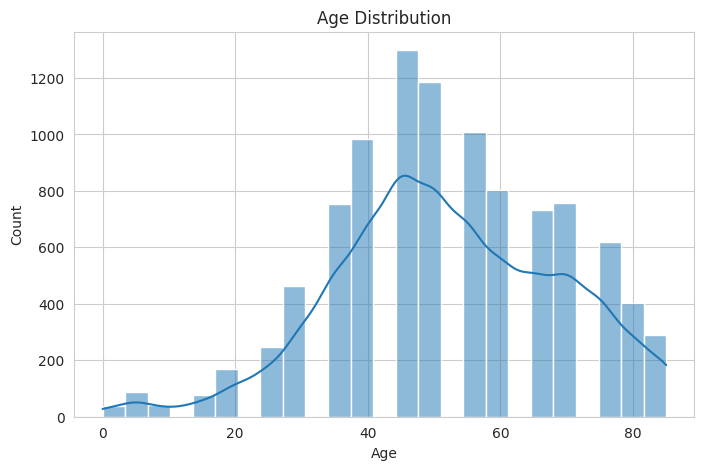

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(metadata['age'],
             bins=25,
             kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

**Boxplot of Age**

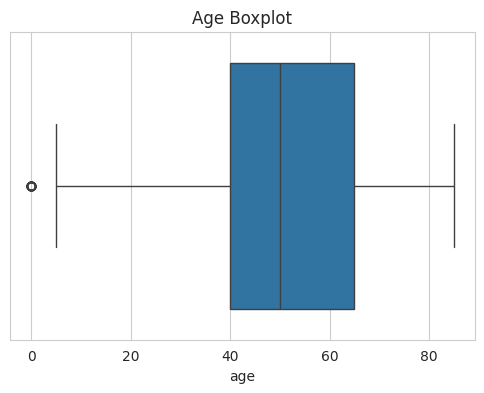

In [14]:
plt.figure(figsize=(6,4))

sns.boxplot(x=metadata['age'])

plt.title("Age Boxplot")
plt.show()

**Lesion Localization**

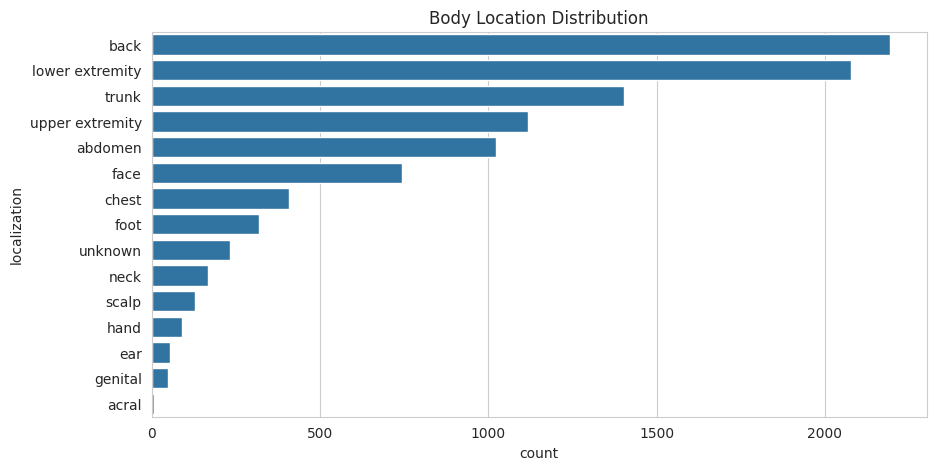

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(data=metadata,
              y='localization',
              order=metadata['localization'].value_counts().index)

plt.title("Body Location Distribution")
plt.show()

**Diagnosis Type**

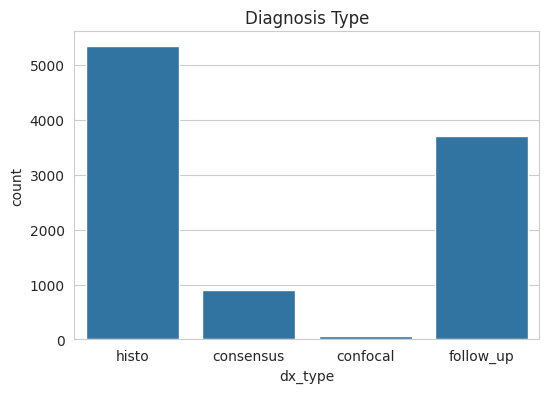

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=metadata,
              x='dx_type')

plt.title("Diagnosis Type")
plt.show()

**Age vs Disease**

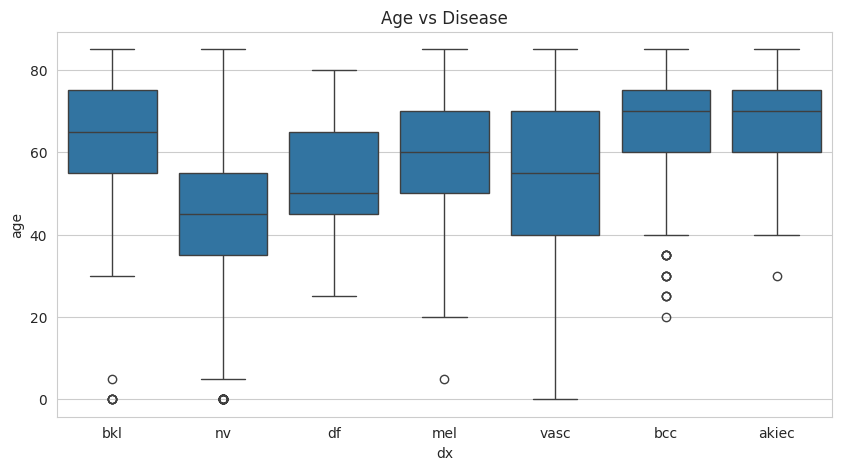

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(data=metadata,
            x='dx',
            y='age')

plt.title("Age vs Disease")
plt.show()

**Gender vs Disease**

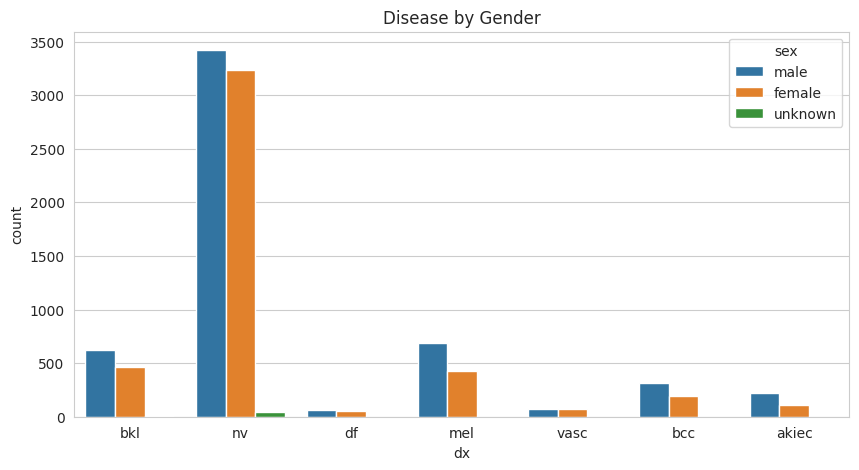

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(data=metadata,
              x='dx',
              hue='sex')

plt.title("Disease by Gender")
plt.show()

**Disease by Body Location**

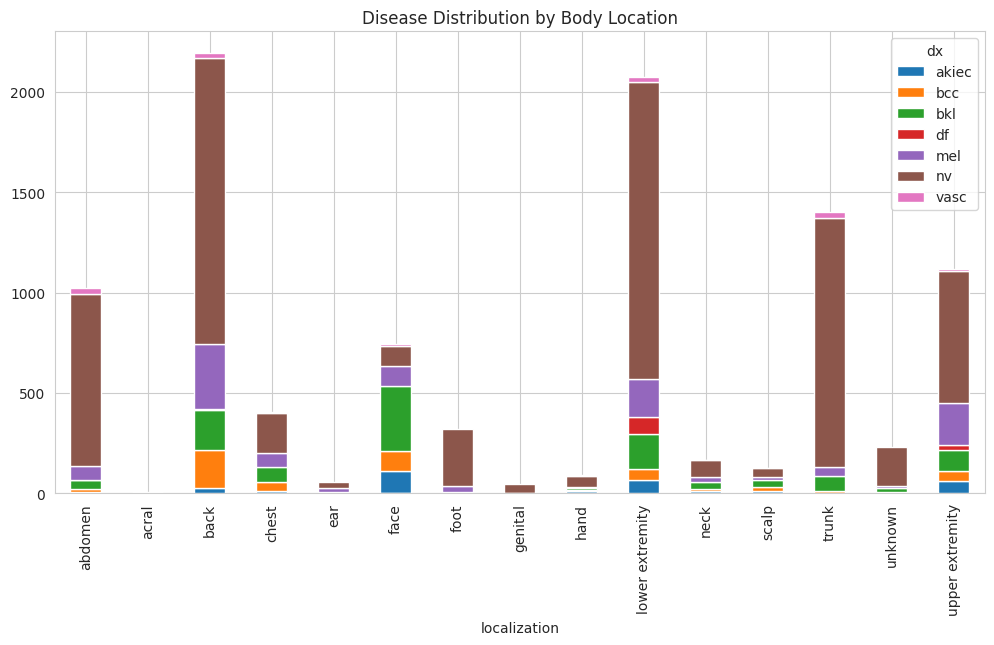

In [19]:
cross = pd.crosstab(metadata['localization'],
                    metadata['dx'])

cross.plot(kind='bar',
           stacked=True,
           figsize=(12,6))

plt.title("Disease Distribution by Body Location")
plt.show()

**Correlation (Numerical)**

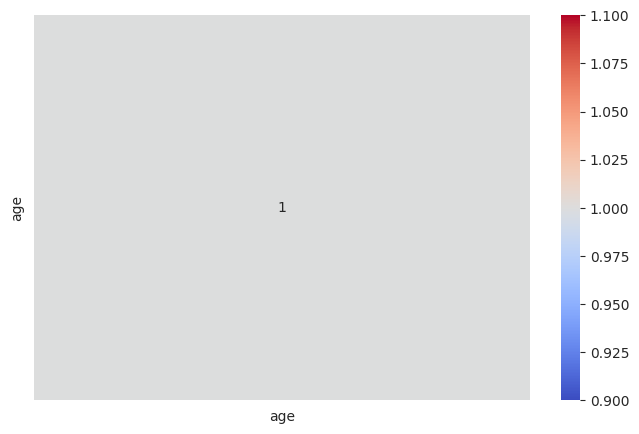

In [20]:
numeric = metadata[['age']]

sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

**Sample Images**

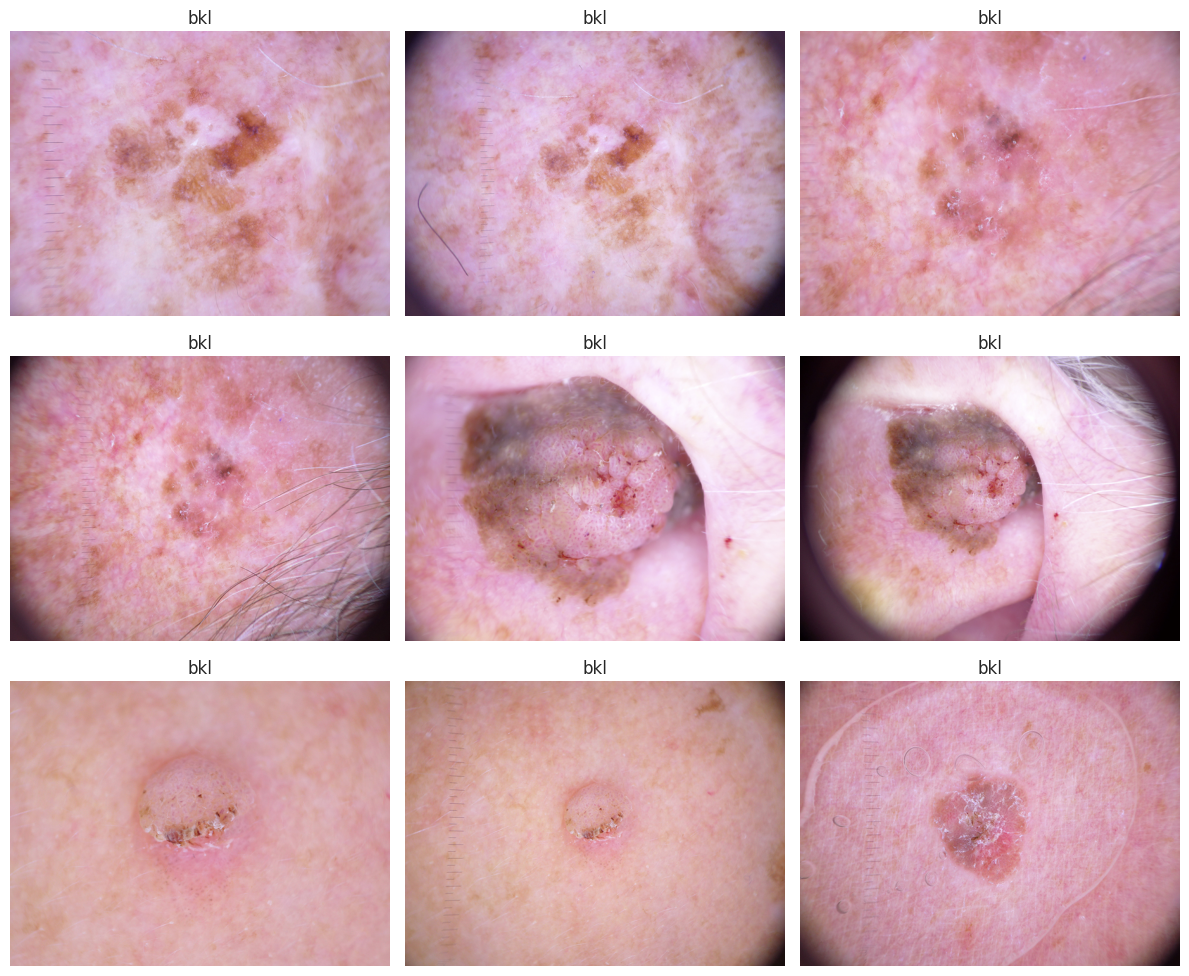

In [36]:
import os
from PIL import Image
import matplotlib.pyplot as plt

part1 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
part2 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"

plt.figure(figsize=(12,10))

for i in range(9):

    image_name = metadata.iloc[i]["image_id"] + ".jpg"

    path1 = os.path.join(part1, image_name)
    path2 = os.path.join(part2, image_name)

    if os.path.exists(path1):
        img = Image.open(path1)
    else:
        img = Image.open(path2)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(metadata.iloc[i]["dx"])
    plt.axis("off")

plt.tight_layout()
plt.show()

**Image Size Distribution**

In [37]:
sizes = []

for i in range(len(metadata)):

    image_name = metadata.iloc[i]["image_id"] + ".jpg"

    path1 = os.path.join(part1, image_name)
    path2 = os.path.join(part2, image_name)

    if os.path.exists(path1):
        img = Image.open(path1)
    elif os.path.exists(path2):
        img = Image.open(path2)
    else:
        continue

    sizes.append(img.size)

sizes = pd.DataFrame(sizes, columns=["Width", "Height"])

sizes.describe()

,Width,Height
count,10015.0,10015.0
mean,600.0,450.0
std,0.0,0.0
min,600.0,450.0
25%,600.0,450.0
50%,600.0,450.0
75%,600.0,450.0
max,600.0,450.0
